# **Lista de exercícios**: *Revisão de AlgeLin*

Prof. Dr. Rodrigo Colnago Contreras <br />
contreras@unifesp.br

---

### Exercício 1)
O código abaixo gera uma matriz $\mathbf{X}$ cujas colunas são vetores em um espaço de dimensão 7. Construa uma matriz $\mathbf{P}$ com 100 colunas onde cada coluna corresponde a um ponto no subespaço coluna de $\mathbf{X}$.

```python
X = np.random.uniform(0,1,size=(7,3))
```

In [1]:
# Solução
import numpy as np

# Gerando a matriz X original (base do subespaço)
X = np.random.uniform(0, 1, size=(7, 3))

# Para criar 100 pontos no subespaço de X, geramos 100 vetores de coeficientes.
# Cada coluna de W representa os pesos da combinação linear das colunas de X.
W = np.random.uniform(-1, 1, size=(3, 100))

# A matriz P é o resultado da multiplicação matricial
# (7x3) @ (3x100) -> (7x100)
P = X @ W

print(f"Formato da matriz P: {P.shape}")

Formato da matriz P: (7, 100)


### Exercício 2)

Construa uma transformação linear que leva vetores de $\mathbb{R}^5$ para o sub-espaço $S$ gerado pelos vetores $(1,1,1)$ e $(0,0,1)$ em $\mathbb{R}^3$. Como você pode verificar que a transformação obtida está realizando o mapeamento desejado?

In [2]:
# SOLUÇÃO
import numpy as np

# Definindo a matriz A (3x5)
A = np.array([
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0]
])

# Gerando um vetor aleatório em R^5
v = np.random.randn(5, 1)

# Aplicando a transformação
w = A @ v
print("Vetor resultante em R^3:\n", w)

Vetor resultante em R^3:
 [[0.54568414]
 [0.54568414]
 [1.74289085]]


### Exercício 3)
O produto escalar entre dois vetores $\mathbf{u}_1$ e $\mathbf{u}_2$ pode ser utilizado para calcular o ângulo entre tais vetores atravéz da fórmula:

$$
\cos(\theta)=\frac{<\mathbf{u}_1,\mathbf{u}_2>}{\|\mathbf{u}_1\|\,\|\mathbf{u}_2\|}
\quad\Longrightarrow\quad
\theta = \arccos\left(\frac{<\mathbf{u}_1,\mathbf{u}_2>}{\|\mathbf{u}_1\|\,\|\mathbf{u}_2\|}\right)
$$

Utilize o resultado acima para encontrar o menor ângulo entre as retas $y+x=1$ e $2y-x=1$.

In [3]:
# Solução
import numpy as np

# Definindo os vetores diretores
u1 = np.array([1, -1])
u2 = np.array([2, 1])

# Calculando o produto escalar e as normas
dot_product = np.dot(u1, u2)
norm_u1 = np.linalg.norm(u1)
norm_u2 = np.linalg.norm(u2)

# Calculando o cosseno
cos_theta = dot_product / (norm_u1 * norm_u2)

# Calculando o ângulo em radianos e depois para graus
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print(f"O ângulo entre as retas é: {theta_deg:.2f}°")

O ângulo entre as retas é: 71.57°


### Exercício 4)
Considere o subespaço $\mathcal{S}$ gerado pelos vetores
$$
\mathbf{u_1} = \left[\begin{array}{c}
                3 \\ 4 \\ 4 \\ 6 \\ 1
                \end{array}\right] \qquad               
\mathbf{u_2} = \left[\begin{array}{c}
                7 \\ 1 \\ 0 \\ 2 \\ 1
                \end{array}\right]
$$

Construa uma transformação linear $\mathbf{A}$ tal que $\mathbf{A}:\mathbb{R}^2\rightarrow\mathcal{S}\subset\mathbb{R}^5$, ou seja, a transformação $\mathbf{A}$ leva vetores do espaço $\mathbb{R}^2$ para o espaço $\mathcal{S}$.

In [5]:
# Solução
import numpy as np

# Definindo os vetores u1 e u2 como vetores coluna
u1 = np.array([[3], [4], [4], [6], [1]])
u2 = np.array([[7], [1], [0], [2], [1]])

# Construindo a matriz A (5x2) usando os vetores como colunas
A = np.hstack((u1, u2))

print("Matriz de Transformação A (5x2):")
print(A)

# Testando a transformação com um vetor aleatório v em R^2
v = np.random.randn(2, 1)
w = A @ v

print("\nVetor v (em R^2):")
print(v)
print("\nVetor resultante w = A @ v (em R^5 e dentro de S):")
print(w)

# Verificando se o posto da matriz com [u1, u2, w] ainda é 2
check_matrix = np.hstack((A, w))
rank = np.linalg.matrix_rank(check_matrix)

print(f"\nO posto da matriz [u1, u2, w] é: {rank}")
# Se o rank for 2, significa que w não adicionou uma nova dimensão,
# logo, ele é uma combinação linear de u1 e u2.

Matriz de Transformação A (5x2):
[[3 7]
 [4 1]
 [4 0]
 [6 2]
 [1 1]]

Vetor v (em R^2):
[[ 1.36823482]
 [-0.15688895]]

Vetor resultante w = A @ v (em R^5 e dentro de S):
[[3.00648178]
 [5.31605031]
 [5.47293926]
 [7.89563099]
 [1.21134586]]

O posto da matriz [u1, u2, w] é: 2


### Exercício 5)
Mostre que para qualquer matriz $\mathbf{A}$ com colunas LI, a matriz $\mathbf{A}^\top\mathbf{A}$ é simétrica e semi-definida positiva.

In [6]:
# Solução
import numpy as np

# Criando uma matriz A com colunas LI (ex: 5x3)
A = np.random.randn(5, 3)

# Calculando M = A.T @ A
M = A.T @ A

# 1. Verificar Simetria (M deve ser igual a M.T)
is_symmetric = np.allclose(M, M.T)

# 2. Verificar se é Definida Positiva (Autovalores > 0)
eigenvalues = np.linalg.eigvals(M)
is_positive_definite = np.all(eigenvalues > 0)

print(f"É simétrica? {is_symmetric}")
print(f"Autovalores: {eigenvalues}")
print(f"É definida positiva? {is_positive_definite}")

É simétrica? True
Autovalores: [3.41631834 4.17796489 6.23037895]
É definida positiva? True


### Exercício 6)
Construa uma matriz $\mathbf{A}$ definida positiva  $10\times 10$ e verifique que o produto $\mathbf{x}^\top\mathbf{A}\mathbf{x}>0$ para alguns vetores $\mathbf{x}$.

In [7]:
# Solução
import numpy as np

# 1. Criar uma matriz auxiliar 10x10
M = np.random.randn(10, 10)

# 2. Gerar a matriz A simétrica e definida positiva
# A = M.T @ M
A = np.dot(M.T, M)

# Opcional: adicionar um pequeno valor à diagonal para garantir
# que seja estritamente positiva (evita problemas de precisão numérica)
A += np.eye(10) * 1e-6

print("Matriz A (10x10) criada com sucesso.")

# 3. Verificação: Testando x.T @ A @ x > 0 para vetores aleatórios
for i in range(5):
    x = np.random.randn(10, 1)
    # Calculando o produto quadrático: x.T * A * x
    resultado = x.T @ A @ x
    print(f"Teste {i+1}: x.T @ A @ x = {resultado[0][0]:.4f}")

Matriz A (10x10) criada com sucesso.
Teste 1: x.T @ A @ x = 236.3939
Teste 2: x.T @ A @ x = 42.0133
Teste 3: x.T @ A @ x = 159.7397
Teste 4: x.T @ A @ x = 57.9234
Teste 5: x.T @ A @ x = 108.9333


### Exercício 7)
Construa uma transformação linear que mapeia o vetor $\mathbf{v}=[1,1,1,1,1]\in\mathbb{R}^5$ nele mesmo, ou seja, a transformação deve satisfazer

$$
\mathbf{A}\mathbf{v}=\mathbf{v}
$$

In [8]:
# Solução
import numpy as np

# Definindo o vetor v
v = np.array([[1], [1], [1], [1], [1]])

# Opção A: Matriz Identidade (Simples)
A_id = np.eye(5)

# Opção B: Matriz de Projeção (Mais elegante)
# A = (v @ v.T) / (v.T @ v)
A_proj = (v @ v.T) / np.sum(v**2)

# Verificação
res_id = A_id @ v
res_proj = A_proj @ v

print("Resultado com Identidade:\n", res_id.flatten())
print("\nResultado com Projeção:\n", res_proj.flatten())

# Verificando se Av == v
print(f"\nA_proj @ v é igual a v? {np.allclose(res_proj, v)}")

Resultado com Identidade:
 [1. 1. 1. 1. 1.]

Resultado com Projeção:
 [1. 1. 1. 1. 1.]

A_proj @ v é igual a v? True


### Exercício 8)
Considere o conjunto de pontos $\{(x_i,y_i): i \in \{1,2,3,...,n\}\}$ definido no código abaixo. Encontre os coeficientes $\alpha_i$ do polinômio:
$$
P(x)=\alpha_0+\alpha_1x+\alpha_2x^2+\cdots+\alpha_5x^5
$$
tal que o erro
$$
E(\alpha)=\sum_i\|P(x_i)-y_i\|^2
$$
Seja o menor possível.

Coeficientes encontrados (alpha_0 a alpha_5):
alpha_0: 0.9651
alpha_1: 1.6048
alpha_2: -3.5232
alpha_3: 2.1331
alpha_4: -0.7686
alpha_5: 0.1310


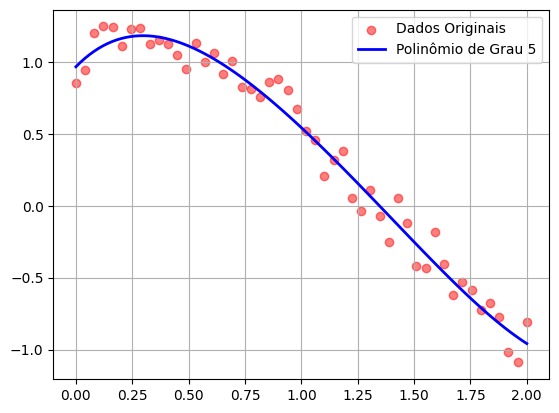

In [9]:
# Solução
import numpy as np
import matplotlib.pyplot as plt

# --- Geração de dados (Exemplo, substitua pelo seu código original) ---
n = 50
x = np.linspace(0, 2, n)
y = 0.5 * x**3 - 2 * x**2 + x + 1 + np.random.normal(0, 0.1, n)
# ---------------------------------------------------------------------

# 1. Construir a Matriz de Vandermonde para grau 5
# Podemos fazer manualmente ou usar np.vander
X = np.vander(x, 6, increasing=True)

# 2. Resolver as Equações Normais: alpha = (X.T @ X)^-1 @ X.T @ y
# Dica: np.linalg.lstsq é numericamente mais estável que inverter a matriz
alpha, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("Coeficientes encontrados (alpha_0 a alpha_5):")
for i, a in enumerate(alpha):
    print(f"alpha_{i}: {a:.4f}")

# --- Visualização ---
plt.scatter(x, y, label='Dados Originais', color='red', alpha=0.5)
x_plot = np.linspace(min(x), max(x), 100)
X_plot = np.vander(x_plot, 6, increasing=True)
y_plot = X_plot @ alpha

plt.plot(x_plot, y_plot, label='Polinômio de Grau 5', color='blue', lw=2)
plt.legend()
plt.grid(True)
plt.show()

### Exercício 9)
Encontre uma trasformação linear cujos autovetores são $v_1=[1,1]$ e $v_2=[1,-1]$ e os autovalores correspondentes são $a_1$ e $a_2$, respectivamente. Os valores de $a_1$ e $a_2$ devem ser escolhidos por você. Verifique graficamente o efeito desta transformação no círculo $x^2+y^2=1$.
O que acontece quando $a_1 = a_2$, $a_1 > a_2$ e $a_1 < a_2$?

Matriz de Transformação A (a1=3.0, a2=1.0):
 [[2. 1.]
 [1. 2.]]


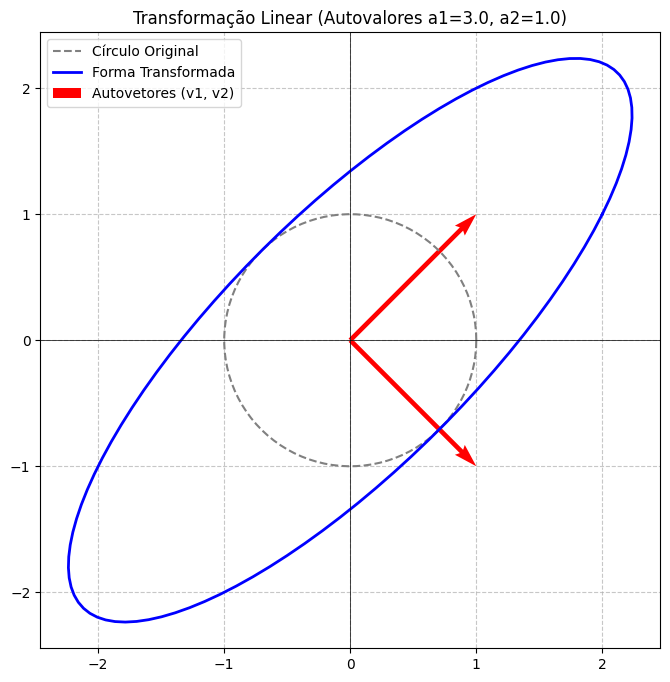

In [10]:
# SOLUÇÃO
import numpy as np
import matplotlib.pyplot as plt

# --- Definição da Transformação ---
# Autovetores fornecidos
v1 = np.array([1, 1])
v2 = np.array([1, -1])

# Matriz P dos autovetores
P = np.stack((v1, v2), axis=1)

# Escolha os autovalores aqui
a1 = 3.0
a2 = 1.0

# Matriz Diagonal D dos autovalores
D = np.diag([a1, a2])

# Matriz de Transformação A = P @ D @ P^-1
A = P @ D @ np.linalg.inv(P)

print(f"Matriz de Transformação A (a1={a1}, a2={a2}):\n", A)

# --- Visualização Gráfica ---
def plot_transformation(A, a1, a2):
    # 1. Gerar o círculo unitário
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])

    # 2. Aplicar a transformação A ao círculo
    transformed_circle = A @ circle

    # 3. Plotar
    plt.figure(figsize=(8, 8))

    # Círculo original
    plt.plot(circle[0, :], circle[1, :], color='gray', linestyle='--', label='Círculo Original')

    # Forma transformada (elipse)
    plt.plot(transformed_circle[0, :], transformed_circle[1, :], color='blue', lw=2, label='Forma Transformada')

    # Vetores de autovetores
    plt.quiver([0, 0], [0, 0], [1, 1], [1, -1], angles='xy', scale_units='xy', scale=1, color='red', label='Autovetores (v1, v2)')

    # Configurações do plot
    title = f'Transformação Linear (Autovalores a1={a1}, a2={a2})'
    plt.title(title)
    plt.xlim(-max(a1, a2)-0.5, max(a1, a2)+0.5)
    plt.ylim(-max(a1, a2)-0.5, max(a1, a2)+0.5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.axis('equal') # Garante que 1 unidade em x seja igual a 1 unidade em y
    plt.show()

# Rodar a visualização inicial
plot_transformation(A, a1, a2)

### Exercício 10)
Considere a forma quadrática abaixo:
$$
f(x,y,z)=x^2+3y^2+z^2-2xy+xz+3yz
$$
Verifique se a forma quadrática é definida positiva.

In [11]:
# Solução
import numpy as np

# Definindo a matriz associada A
A = np.array([
    [1,   -1,   0.5],
    [-1,   3,   1.5],
    [0.5, 1.5,  1  ]
])

# Calculando os autovalores
autovalores = np.linalg.eigvals(A)

print("Autovalores da matriz A:")
print(autovalores)

# Verificação
if np.all(autovalores > 0):
    print("\nA forma quadrática É definida positiva.")
else:
    print("\nA forma quadrática NÃO é definida positiva.")

Autovalores da matriz A:
[-0.42892105  1.47360701  3.95531403]

A forma quadrática NÃO é definida positiva.


### Exercício 11)
Considere a função $f(x)=\exp(-x^2)$, $x\in[0,1]$. Usando o método dos mínimos quadrados, aproxime a função $f(x)$ por um polinômio quadrático e por um polinômio cúbico. Verifique o erro médio quadrático em cada um dos casos.

MSE Quadrático (Grau 2): 0.00012077
MSE Cúbico (Grau 3):     0.00000012


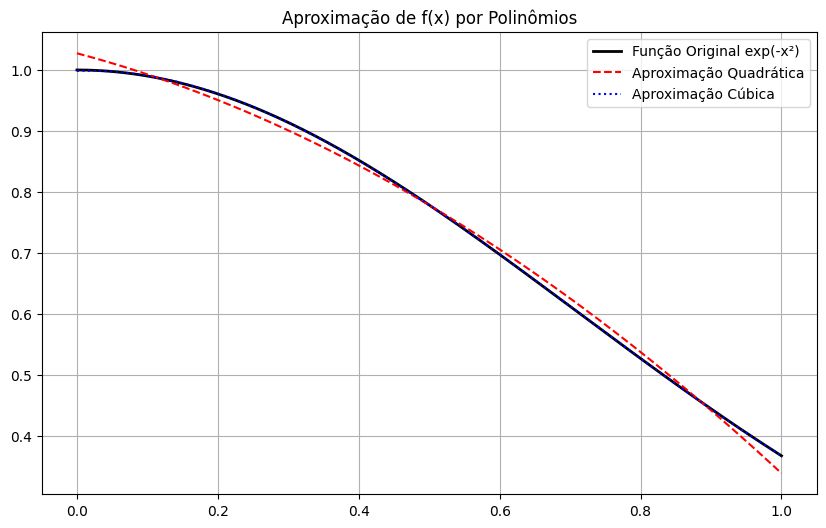

In [12]:
# Solução
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir a função e o intervalo
def f(x):
    return np.exp(-x**2)

x = np.linspace(0, 1, 1000)
y = f(x)

# 2. Função para calcular os coeficientes e o erro
def aproximar_polinomio(x, y, grau):
    # Matriz de Vandermonde
    X = np.vander(x, grau + 1, increasing=True)

    # Resolver Mínimos Quadrados: alpha = (X.T @ X)^-1 @ X.T @ y
    alpha, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    # Predição
    y_pred = X @ alpha

    # Erro Médio Quadrático (MSE)
    mse = np.mean((y - y_pred)**2)

    return alpha, y_pred, mse

# 3. Calcular para grau 2 (quadrático) e grau 3 (cúbico)
alpha2, y2, mse2 = aproximar_polinomio(x, y, 2)
alpha3, y3, mse3 = aproximar_polinomio(x, y, 3)

# 4. Resultados
print(f"MSE Quadrático (Grau 2): {mse2:.8f}")
print(f"MSE Cúbico (Grau 3):     {mse3:.8f}")

# 5. Visualização
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k', label='Função Original exp(-x²)', lw=2)
plt.plot(x, y2, '--r', label='Aproximação Quadrática')
plt.plot(x, y3, ':b', label='Aproximação Cúbica')
plt.title('Aproximação de f(x) por Polinômios')
plt.legend()
plt.grid(True)
plt.show()

### Exercício 12)
Utiliza mínimos quadrados para aproximar a função

$$
f(x)=(x^3-1)^2, \quad x\in[0,1]
$$

por uma reta $r(x)=a+bx$, de modo que o erro médio quadrático seja mínimo e que a reta passe pelo ponto $r(1)=0$.

Coeficientes encontrados: a = 1.2532, b = -1.2532
Equação da reta: r(x) = 1.2532 + (-1.2532)x
Verificação r(1): 0.0000


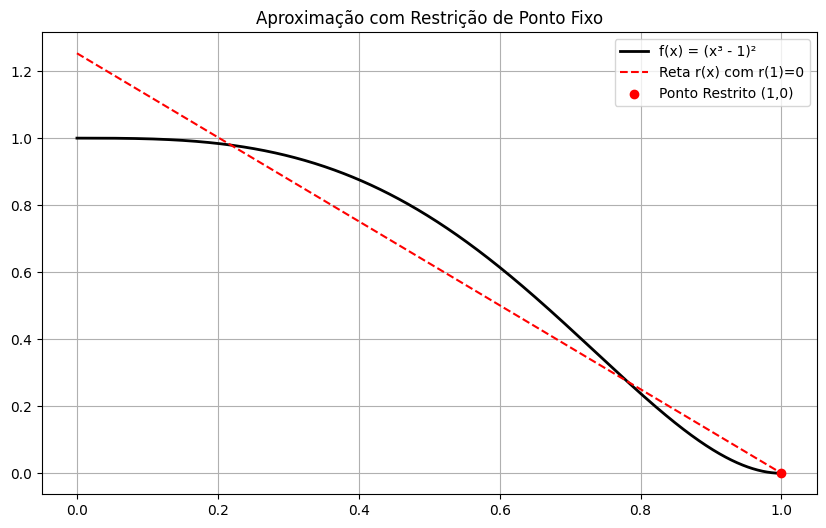

In [13]:
# Solução
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir a função f(x)
def f(x):
    return (x**3 - 1)**2

x = np.linspace(0, 1, 1000)
y = f(x)

# 2. Definir a matriz de projeto com a restrição embutida
# Como r(x) = b(x - 1), nossa "matriz" X tem apenas uma coluna: (x - 1)
X = (x - 1).reshape(-1, 1)

# 3. Resolver por Mínimos Quadrados para encontrar b
# b = (X.T @ X)^-1 @ X.T @ y
b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
b = b[0]
a = -b

print(f"Coeficientes encontrados: a = {a:.4f}, b = {b:.4f}")
print(f"Equação da reta: r(x) = {a:.4f} + ({b:.4f})x")

# 4. Verificação de r(1)
print(f"Verificação r(1): {a + b:.4f}")

# 5. Visualização
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k', label='f(x) = (x³ - 1)²', lw=2)
plt.plot(x, a + b*x, '--r', label='Reta r(x) com r(1)=0')
plt.scatter([1], [0], color='red', zorder=5, label='Ponto Restrito (1,0)')
plt.title('Aproximação com Restrição de Ponto Fixo')
plt.legend()
plt.grid(True)
plt.show()